<a href="https://colab.research.google.com/github/fehmidataj27-dotcom/desktop-tutorial/blob/main/detective%20victums%20of%20human.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================
# PIECE 1 — IMPORT LIBRARIES
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

import joblib
import os


In [ ]:
# ============================
# PIECE 2 — LOAD DATA + INFO
# ============================

# Dataset path
file_path = "/content/detected-victims-of-human-trafficking-female.csv"

# Load CSV
df = pd.read_csv(file_path)

print("===== FILE LOADED =====")
print("File Path:", file_path)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())

print("\n===== FIRST 5 ROWS =====")
print(df.head())


===== FILE LOADED =====
File Path: /content/detected-victims-of-human-trafficking-female.csv
Shape: (16, 26)

Columns: ['Date', 'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Cameroon', 'Eswatini', 'Ghana', 'Guinea', 'Kenya', 'Madagascar', 'Mali', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sierra Leone', 'South Africa', 'Sudan', 'Togo', 'Tunisia', 'Uganda']

===== DATA TYPES =====
Date             object
Algeria         float64
Angola          float64
Benin           float64
Botswana        float64
Burkina Faso    float64
Cameroon        float64
Eswatini        float64
Ghana           float64
Guinea          float64
Kenya           float64
Madagascar      float64
Mali            float64
Mauritius       float64
Morocco         float64
Mozambique      float64
Namibia         float64
Niger           float64
Nigeria         float64
Rwanda          float64
Sierra Leone    float64
South Africa    float64
Sudan           float64
Togo           

In [ ]:
# ============================
# PIECE 3 — DATA CLEANING
# ============================

# Replace all missing values with 0
df = df.fillna(0)

print("Cleaning Completed: Missing values replaced.")


Cleaning Completed: Missing values replaced.


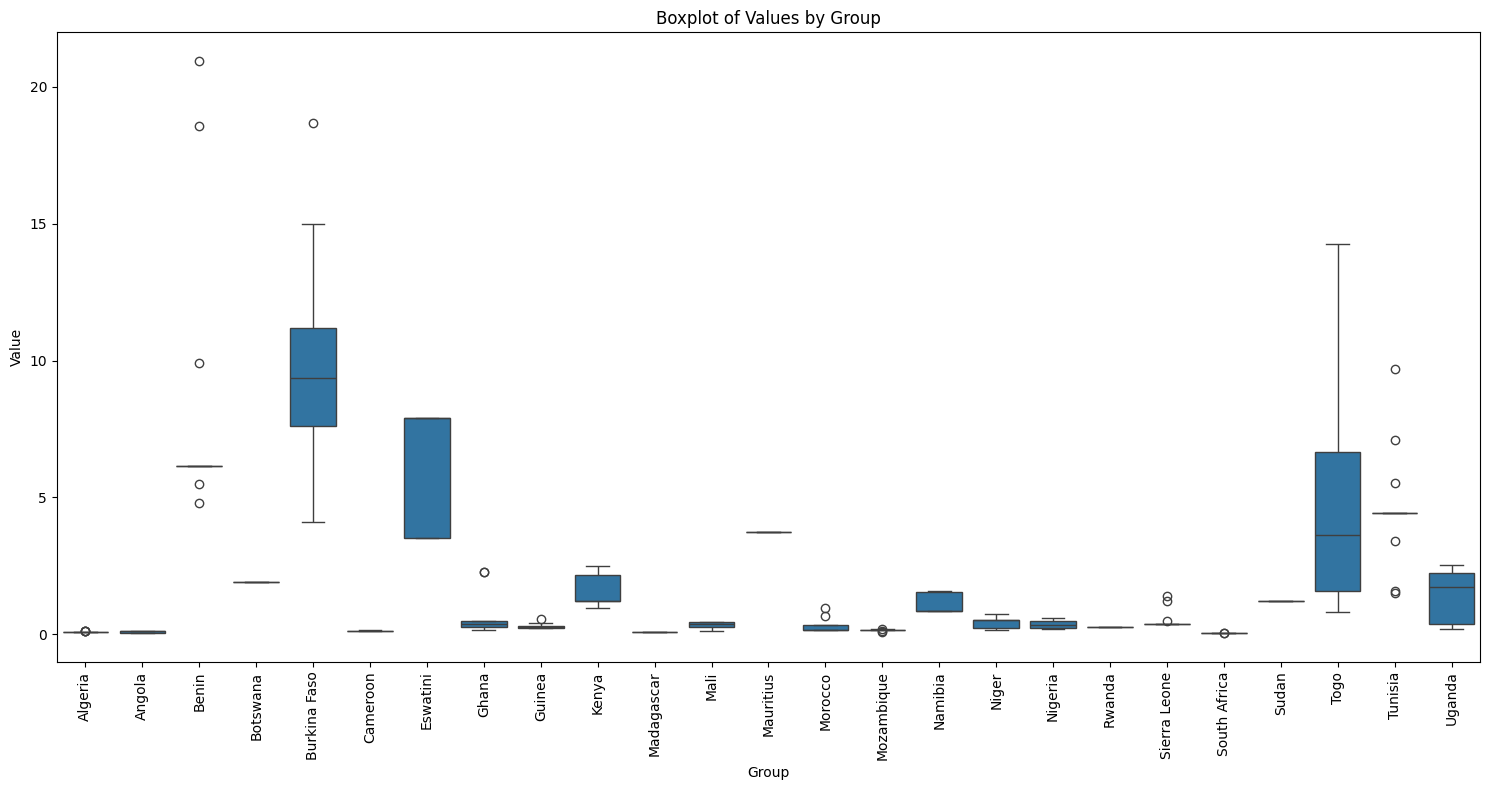

In [ ]:
# Step 2: Plot boxplot
plt.figure(figsize=(15,8)) # Increased figsize for better readability
sns.boxplot(x='Group', y='Value', data=melted_df)
plt.title('Boxplot of Values by Group')
plt.ylabel('Value')
plt.xlabel('Group')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

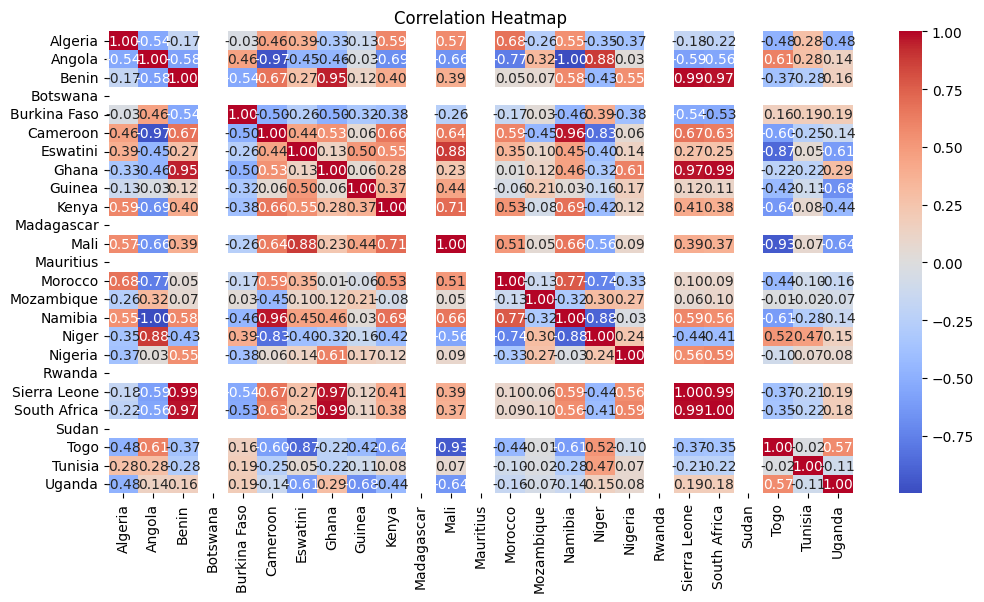

In [ ]:
# ============================
# PIECE 4 — EDA + HEATMAP
# ============================

plt.figure(figsize=(12,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# ============================
# PIECE 5 — TRAIN/TEST SPLIT
# ============================

target_column = df.columns[-1]   # using last column as target (change if needed)

# Drop the 'Date' column as it's not a numerical feature for scaling
X = df.drop([target_column, 'Date'], axis=1)
y = df[target_column]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train/Test splitting and scaling completed.")

Train/Test splitting and scaling completed.


In [ ]:
# ============================
# PIECE 6 — MODEL TRAINING
# ============================

# Changed from RandomForestClassifier to RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
# ============================
# PIECE 7 — MODEL TESTING
# ============================

from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

print("===== REGRESSION METRICS ====")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))


===== REGRESSION METRICS ====
Mean Squared Error: 0.12452529812499888
R-squared: 0.3859699303501044


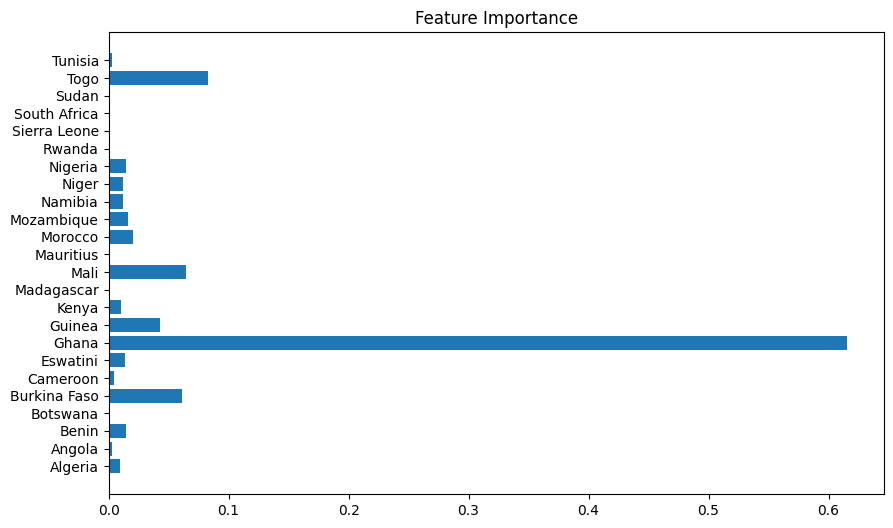

In [ ]:
# ============================
# PIECE 8 — FEATURE IMPORTANCE
# ============================

plt.figure(figsize=(10,6))
importance = model.feature_importances_
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()


In [ ]:
# ============================
# PIECE 9 — SAVE MODEL
# ============================

if not os.path.exists("models"):
    os.makedirs("models")

joblib.dump(model, "models/advanced_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model saved at: models/advanced_model.pkl")
print("Scaler saved at: models/scaler.pkl")


Model saved at: models/advanced_model.pkl
Scaler saved at: models/scaler.pkl
